In [ ]:
## Preparer data
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
import matplotlib.pyplot as plt

## Project Structure
project_root = Path.cwd().parent

data_dir = project_root / "data"

boundary_dir = data_dir / "boundaries"

lc_dir = Path("/Volumes/HOLMES/SATELLITE/landsat")

output_dir = project_root / "outputs"

/Volumes/HOLMES/SATELLITE/landsat


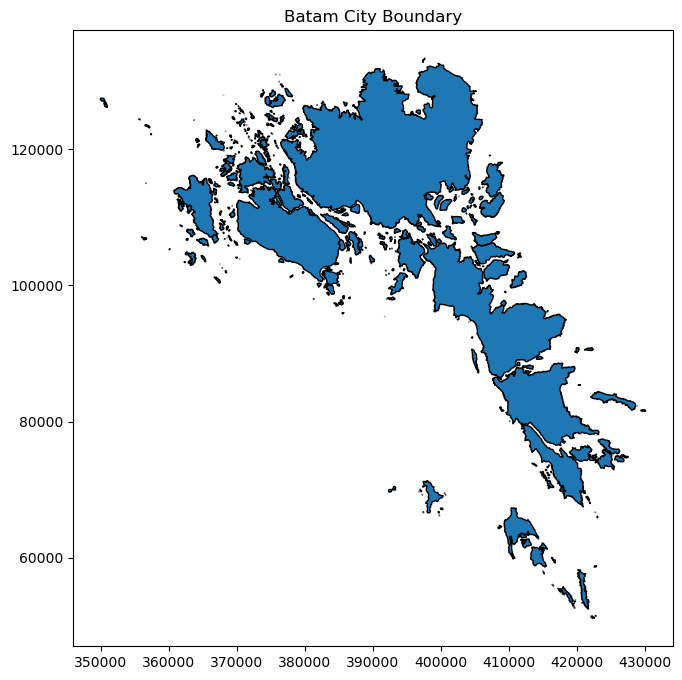

In [ ]:
## Read boundary
kota = gpd.read_file(
    boundary_dir / 
    "KOTA BATAM/kota_utm.geojson"
)

kecamatan = gpd.read_file(
    boundary_dir / 
    "KOTA BATAM/kecamatan_utm.geojson"
)

## Plot baoundary
fig, ax = plt.subplots(
    figsize=(8,8)
)

kota.plot(
    ax=ax,
    edgecolor="black"
)

ax.set_title(
    "Batam City Boundary"
)

plt.show()

In [10]:
print(
    "kota CRS:",
    kota.crs
)

print(
    "kecamatan CRS:",
    kecamatan.crs
)

kota CRS: EPSG:32648
kecamatan CRS: EPSG:32648


In [ ]:
## Total Bounds
## to get minimum and maximum number of X, Y

kota.total_bounds

array([349952.44093109,  51132.21256721, 430030.81127473, 133360.25433431])

In [15]:
batam_bounds = kota.total_bounds

print(
    f"Min X : {batam_bounds[0]}"
)

print(
    f"Min X : {batam_bounds[1]}"
)

print(
    f"Min X : {batam_bounds[2]}"
)

print(
    f"Min X : {batam_bounds[3]}"
)

Min X : 349952.4409310877
Min X : 51132.21256721078
Min X : 430030.81127472804
Min X : 133360.25433430925


In [6]:
## Landsat data section
## you can adjust the directory path of your Landsat Data

landsat_dates = {
    "20250706":
    lc_dir / "20250706",

    "20251205":
    lc_dir / "20251205"
}

## Open sample bands.
## we will test to open band 4 and 5

sample4 = rio.open(
    landsat_dates["20250706"] / 
    "LC09_L2SP_125059_20250706_20250707_02_T1_SR_B4.TIF"
)

In [7]:
print(
    sample4.crs
)

print(
    sample4.width,
    sample4.height
)

print(
    sample4.bounds
)

EPSG:32648
7591 7741
BoundingBox(left=289485.0, bottom=43485.0, right=517215.0, top=275715.0)


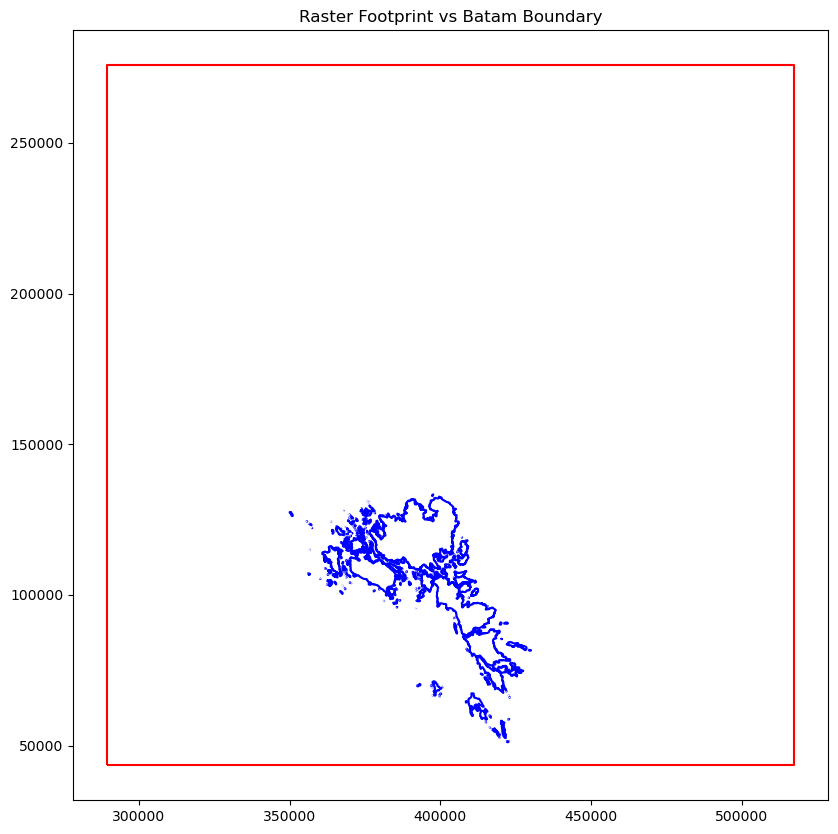

In [12]:
from shapely.geometry import box

## Read boundary
kota = gpd.read_file(
    boundary_dir / 
    "KOTA BATAM/kota_utm.geojson"
)

raster_extent = gpd.GeoDataFrame(
    geometry=[
        box(
            *sample4.bounds
        )
    ],
    crs=sample4.crs
)

fig, ax = plt.subplots(
    figsize = (10,10)
)

raster_extent.boundary.plot(
    ax=ax,
    color="red"
)

kota.boundary.plot(\
    ax=ax,
    color="blue"
)

plt.title(
    "Raster Footprint vs Batam Boundary"
)

plt.show()